In [7]:
from sqlalchemy import create_engine
import pandas as pd

username = "postgres"
password = "appuappu"
host = "localhost"
port = "5432"
database = "MYDATABASE1"

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

print("Connection created")

Connection created


In [8]:
query = """
SELECT 
    channel,
    SUM(total_sales) AS revenue,
    ROUND(
        100.0 * SUM(total_sales) / SUM(SUM(total_sales)) OVER (),
        2
    ) AS percentage
FROM "Omnichannel"
GROUP BY channel;
"""
channel_perf = pd.read_sql(query, engine)
channel_perf

,channel,revenue,percentage
0,Offline,18802277.0,51.64
1,Online,17610453.0,48.36


In [9]:
# to find total revenue
query = """
SELECT SUM(total_sales) AS total_revenue
FROM "Omnichannel";
"""
total_revenue = pd.read_sql(query, engine)
total_revenue


,total_revenue
0,36412730.0


In [10]:
#to find total contribution %
query = """
SELECT 
    channel,
    SUM(total_sales) AS revenue,
    ROUND(
        100.0 * SUM(total_sales) / SUM(SUM(total_sales)) OVER (),
        2
    ) AS percentage
FROM "Omnichannel"
GROUP BY channel;
"""
channel_perf = pd.read_sql(query, engine)
channel_perf

,channel,revenue,percentage
0,Offline,18802277.0,51.64
1,Online,17610453.0,48.36


In [11]:
# To find Monthlt trend and rank

query = """
SELECT 
    year_month,
    SUM(total_sales) AS revenue,
    RANK() OVER (ORDER BY SUM(total_sales) DESC) AS rank_high,
    RANK() OVER (ORDER BY SUM(total_sales)) AS rank_low
FROM "Omnichannel"
GROUP BY year_month
ORDER BY year_month;
"""
monthly_trend = pd.read_sql(query, engine)
monthly_trend

,year_month,revenue,rank_high,rank_low
0,2025-01,1082437.0,9,5
1,2025-02,984060.0,12,2
2,2025-03,1209555.0,6,8
3,2025-04,1136353.0,8,6
4,2025-05,902048.0,13,1
5,2025-06,2005115.0,2,12
6,2025-07,1040713.0,11,3
7,2025-08,1668369.0,3,11
8,2025-09,1483206.0,5,9
9,2025-10,1154989.0,7,7


In [12]:
# Month over month growth

query = """
SELECT 
    year_month,
    SUM(total_sales) AS revenue,
    LAG(SUM(total_sales)) OVER (ORDER BY year_month) AS prev_month,
    ROUND(
        (SUM(total_sales) - LAG(SUM(total_sales)) OVER (ORDER BY year_month))
        * 100.0 / LAG(SUM(total_sales)) OVER (ORDER BY year_month),
        2
    ) AS growth_pct
FROM "Omnichannel"
GROUP BY year_month
ORDER BY year_month;
"""
growth = pd.read_sql(query, engine)
growth

,year_month,revenue,prev_month,growth_pct
0,2025-01,1082437.0,NaN,NaN
1,2025-02,984060.0,1082437.0,-9.09
2,2025-03,1209555.0,984060.0,22.91
3,2025-04,1136353.0,1209555.0,-6.05
4,2025-05,902048.0,1136353.0,-20.62
5,2025-06,2005115.0,902048.0,122.28
6,2025-07,1040713.0,2005115.0,-48.10
7,2025-08,1668369.0,1040713.0,60.31
8,2025-09,1483206.0,1668369.0,-11.10
9,2025-10,1154989.0,1483206.0,-22.13


In [13]:
# Pareto analysis

query = """
WITH product_sales AS (
    SELECT 
        product,
        SUM(total_sales) AS revenue
    FROM "Omnichannel"
    GROUP BY product
),
ranked AS (
    SELECT 
        product,
        revenue,
        SUM(revenue) OVER () AS total_revenue,
        SUM(revenue) OVER (ORDER BY revenue DESC) AS cumulative_revenue
    FROM product_sales
)
SELECT 
    product,
    revenue,
    ROUND(100.0 * revenue / total_revenue, 2) AS pct_contribution,
    ROUND(100.0 * cumulative_revenue / total_revenue, 2) AS cumulative_pct
FROM ranked
ORDER BY revenue DESC;
"""
pareto = pd.read_sql(query, engine)
pareto

,product,revenue,pct_contribution,cumulative_pct
0,Laptop,5374622.0,14.76,14.76
1,Watch,5048915.0,13.87,28.63
2,T-shirt,4876114.0,13.39,42.02
3,Tablet,4611786.0,12.67,54.68
4,Shoes,4475817.0,12.29,66.97
5,Smartphone,4323113.0,11.87,78.85
6,Headphones,4014264.0,11.02,89.87
7,Backpack,3688099.0,10.13,100.00


In [14]:
# To find total city performances

query = """
SELECT 
    city,
    SUM(total_sales) AS revenue,
    RANK() OVER (ORDER BY SUM(total_sales) DESC) AS rank
FROM "Omnichannel"
GROUP BY city
ORDER BY revenue DESC;
"""
city_perf = pd.read_sql(query, engine)
city_perf

,city,revenue,rank
0,Mumbai,6792574.0,1
1,Hyderabad,6756808.0,2
2,Delhi,6552147.0,3
3,Bangalore,6020689.0,4
4,Chennai,5346027.0,5
5,Pune,4944485.0,6


In [15]:
# to find channel over time

query = """
SELECT 
    year_month,
    channel,
    SUM(total_sales) AS revenue,
    ROUND(
        100.0 * SUM(total_sales) /
        SUM(SUM(total_sales)) OVER (PARTITION BY year_month),
        2
    ) AS monthly_share
FROM "Omnichannel"
GROUP BY year_month, channel
ORDER BY year_month;
"""
channel_trend = pd.read_sql(query, engine)
channel_trend

,year_month,channel,revenue,monthly_share
0,2025-01,Online,539587.0,49.85
1,2025-01,Offline,542850.0,50.15
2,2025-02,Online,371299.0,37.73
3,2025-02,Offline,612761.0,62.27
4,2025-03,Online,751043.0,62.09
5,2025-03,Offline,458512.0,37.91
6,2025-04,Online,585723.0,51.54
7,2025-04,Offline,550630.0,48.46
8,2025-05,Offline,414485.0,45.95
9,2025-05,Online,487563.0,54.05


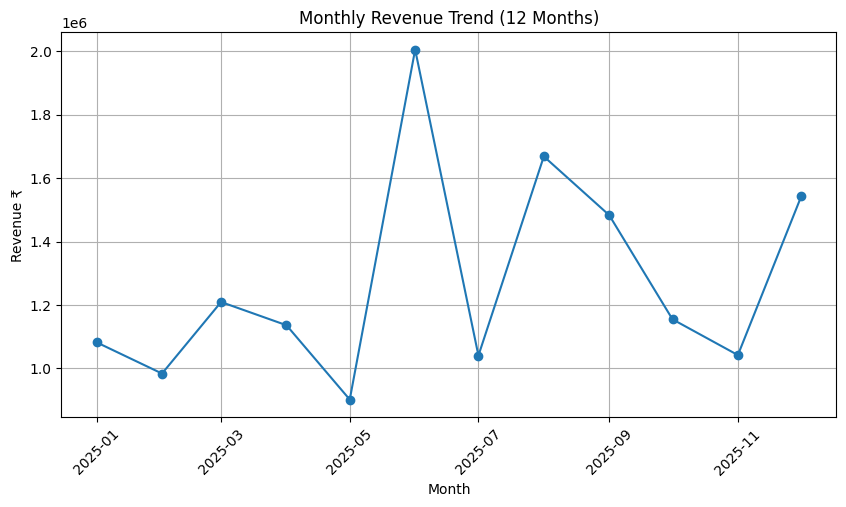

In [20]:
import matplotlib.pyplot as plt

query = """
SELECT 
    year_month,
    SUM(total_sales) AS revenue
FROM "Omnichannel"
GROUP BY year_month
ORDER BY year_month;
"""
df = pd.read_sql(query, engine)
df['year_month'] = pd.to_datetime(df['year_month'])
plt.figure(figsize=(10,5))

plt.plot(df['year_month'], df['revenue'], marker='o')
plt.title("Monthly Revenue Trend (12 Months)")
plt.xlabel("Month")
plt.ylabel("Revenue ₹")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()